# A kontextusablak kiterjesztése nagy nyelvi modellekben: RoPE és YaRN

## Motiváció

A modern nagy nyelvi modellek (LLM-ek) egyik legfontosabb képessége, hogy milyen hosszú kontextust (szöveget) képesek egyszerre feldolgozni. Ahogy egyszerre több feladatnál (pl. teljes könyvek elemzése, hosszú kódbázisok megértése) merül fel az igény a több tízezer vagy százezer tokenes kontextusra, egyértelművé vált, hogy a hagyományos Transformer architektúra nem skálázódik megfelelően.

A Transformerek önfigyelmi (self-attention) mechanizmusa önmagában permutáció-invariáns, azaz nem rendelkezik beépített fogalommal a szavak sorrendjéről. Ezt a problémát pozícionális beágyazásokkal oldjuk meg.

Míg a korai modellek (mint a BERT vagyaz eredeti Transformer) abszolút poziciónális beágyazásokat használtak, a modern LLM-ek (legalábbis a nyílt súlyú modellek, amelyeknél ez az információ elérhető) a RoPE (Rotary Position Embedding) [1] nevű módszert alkalmazzák.

## Miért nem tanítjuk az LLM-eket alapból végtelen kontextusra?

1. A figyelmi mechanizmus memóriaigénye a hossz négyzetével nő ($O(N^2)$).
2. A Transformer alapból "vak" a szavak sorrendjére. Ahhoz, hogy megértse, melyik szó hol van, pozícionális beágyazásokat használunk.

Amikor egy modellt 4000 tokenes hosszon tanítanak be, egyszerűen sosem látja a 4001., vagy a 10000. pozíciót. Ha hirtelen egy 8000 tokenes szöveet kap, megzavarodik a számára ismeretlen pozíciók miatt.

Míg a korai modellek (pl. BERT, eredeti Transformer) abszolót pozíciókat használtak, a modern LLM-ek áttértek a relatív pozíciók kódolására. A jelenlegi iparági sztenderd erre a RoPE.

Azonban komoly kihívást jelent, amikor egy modellt $L_{train}$ (pl. 4k) hosszon tanítanak, de inferencia során $L_{test}$ (pl. 32k) kontextust szeretnénk használni.

## 1. A RoPE (Roterz Position Embedding) elmélete

A relatív pozíciók kódolásának fő célja, hogy a Query és Key vektorok skaláris szorzata a figyelmi mátrixban kizárólag a vektorok tartalmától és relatív távolságuktól függjön.

Kéresünk egy $f$ függvényt, amelyre igaz:

$$ \langle f_q(q_m, m), f_k(k_n, n) \rangle = g(q_m, k_n, m - n) $$

### A komplex forgatás eleganciája

A RoPE alkotói a 2D komplex síkon találták meg a megoldást. Ha pozíciót egy $\theta$ szügű forgatásként értelmezünk, és Euler formuláját ($e^{i\theta}$) használjuk, a vektorok pozícióba ágyazása a következőképp alakul:

$$ f_q(q_m, m) = q_m e^{i m \theta} $$
$$ f_k(k_n, n) = k_n e^{i n \theta} $$

Ha kiszámoljuk a két kopmlex vektor belső szorzatát (amely során a második vektor komplex konjugáltját vesszük, azaz $e^{-i n \theta}$-t):

$$ \langle f_q(q_m, m), f_k(k_n, n) \rangle = \text{Re} \left[ (q_m e^{i m \theta}) (k_n e^{i n \theta})^* \right] = \text{Re} \left[ q_m k_n^* e^{i (m - n) \theta} \right] $$

Ezzel el is értük a célt: a belső szorzat explicit módon csak az $(m - n)$ relatív távolsától függ, miközben az implementáció csupán az abszolút pozícióknak megfelelő forgatást igényel.

Egy $d$-dimenziós modell esetén a teret $d/2$ darab 2D-s altérre bontjuk. Minden altérhez egyedi $\theta_j$ frekvenciát rendelünk, amelyek egy gemoetriai sorozatot alkotnak:

$$ \theta_j = 10000^{-2j/d} \quad \text{ahol } j \in[0, 1, ..., d/2 - 1] $$

Ez azt jelenti, hogy az alacsonyabb dimenziók (kis $j$) magas frekvenciával (gyorsan) forognak, míg a magasabb dimenziók (nagy $j$) alacsony frekvenciával (lassan) forognak.

In [14]:
# RoPE implementáció PyTorch-ban

import torch

def precompute_freqs(dim: int, seq_len: int, base: float = 10_000.0):
    # theta_j = 10000^(-2j/d)
    freqs = 1.0 / (base ** (torch.arange(0, dim, 2)[: (dim // 2)].float() / dim))
    t = torch.arange(seq_len)
    
    freqs = torch.outer(t, freqs).float()
    
    freqs = torch.polar(torch.ones_like(freqs), freqs)

    return freqs

def apply_rotary_embedding(xq: torch.Tensor, xk: torch.Tensor, freqs: torch.Tensor):
    xq_ = torch.view_as_complex(xq.float().reshape(*xq.shape[:-1], -1, 2))
    xk_ = torch.view_as_complex(xq.float().reshape(*xq.shape[:-1], -1, 2))

    xq_out = torch.view_as_real(xq_ * freqs).flatten(3)
    xk_out = torch.view_as_real(xk_ * freqs).flatten(3)

    return xq_out.type_as(xq), xk_out.type_as(xk)

dim = 128
seq_len = 4096
freqs = precompute_freqs(dim, seq_len)

q = torch.randn(1, 8, 100, dim)
k = torch.randn(1, 8, 100, dim)

q_rot, k_rot = apply_rotary_embedding(q, k, freqs[:100])
print(f'Eredeti Q shape: {q.shape}')
print(f'Rotált Q shape: {q_rot.shape}')

Eredeti Q shape: torch.Size([1, 8, 100, 128])
Rotált Q shape: torch.Size([1, 8, 100, 128])


## 2. A skálázás kihívásai: Extrapoláció vs Interpoláció

Mi történik, ha egy 4096 tokenen tanított modellt 16384 tokenes prompttal (4x skálázás) futtatunk?

A modell az $m > 4096$ pozíciókra olyan $m\theta_j$ forgatási szögeket kap, amelyeket a betanítás során sosem látott. Az LLM-ek nagyon rosszul extrapolálnak ezekre az Out-of-Distribution (OOD) értékekre: a figyelmi mértékek eltorzulnak, a perplexitás drasztikusan megnő.

### A Pozíció Interpoláció

A Meta kutatói mutatták be a pozíció interpoláció módszerét. A logika egyszerű: ha az LLM nem tud extrapolálni a $[4096, 16384]$ tartományra, akkor "nyomjuk össze" a hosszú szekvenciát a már ismert $[0, 4096]$ tartományba!

Vezessünk be egy skálázási faktort: $s = \frac{L_{test}}{L_{train}}$ (esetünkben $s = 4$). Az új pozíció: $m' = \frac{m}{s}$.

### A probléma a PI-vel:

Ha minden pozíciót leosztunk $s$-el, akkor a szomszédos szavak közötti távolság (ami eddig $1$ volt, hirtelen $0.25$ lesz.
A modell érzékeny a lokális kontextusra (a szomszédos tokenek határozzák meg a szintaxist, a szavak összetartozását). Ha a kozeli szavakat "összenyomjuk", a modell összezavarodik a lokális mintázatok értelmezésében, ami a teljesítmény romlásához vezet.

## 3. A YaRN (Yet another RoPE extensioN method)

A YaRN egoldja a PI alapvető hibákát azzal a felismeréssel, hogy a RoPE dimenziói nem egyformák. Különböző $\theta_j$ frekvenciák különböző távolságokat kódolnak:

1. Magas frekvenciák (alacsony $j$ index): A lokális kontextust (szomszédos szavak) kódolják.
2. Alascony frekvenciák (magas $j$ index): A globális kontextust (dokumentum szintű struktúra) kódolják.

A YaRN bevezeti a frekvencia-tudatos interpolációt:

- A magas frekvenciájú dimenziókat nem interpolálja ($s_j = 1$). Ezeknél hagyja a modellt extrapolálni, mivel a szomszédos szavak távolságát ($m=1$) nem szabad torzítani.
- Az alacsony frekvenciájú dimenziókat teljesen interpolálja ($s_j = s$), hogy a távoli tokeneknél elkerülje az OOD pozíciókat.
- A kettő között pedig egy sima (Ramp) függvénnyel képez átmenetet.

### Hőmérséklet skálázás

A YaRN egey további finomíŧást is bevezet. Ha a kontextus négyszeresére nő, a softmax függvénynek 4-szer annyi token között kell "elosztania" a figyelmet, ami az entrópiát nőveli.

Ennek ellensúlyozására a pre-softmax logitokat egy $\sqrt{t}$ faktorral szorozzák (ahol $t \approx 0.1 \ln{s} + 1$), ezáltal megőrizve a figyelem "élességét" a megnövelt kontextus ellenére is.

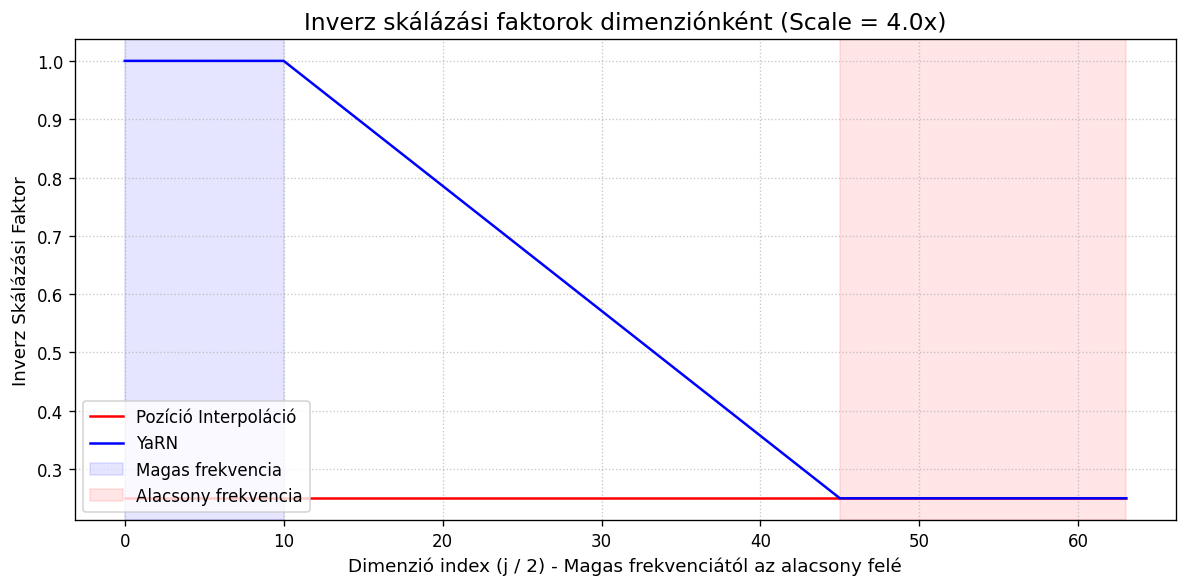

In [25]:
# A dimenziónkénti skálázási faktorok vizualizációja: PI vs YaRN

import matplotlib.pyplot as plt
import numpy as np

def calculate_yarn_scaling_factors(dim: int, scale_factor: float, low_idx: int = 10, high_idx: int = 45):
    num_freqs = dim // 2
    ramp = np.zeros(num_freqs)

    for i in range(num_freqs):
        if i < low_idx:
            ramp[i] = 0.0
        elif i > high_idx:
            ramp[i] = 1.0
        else:
            ramp[i] = (i - low_idx) / (high_idx - low_idx)

    inv_s_j = (1.0 - ramp) + (ramp / scale_factor)
    return inv_s_j

dim = 128
scale_factor = 4.0

pi_scaling = np.full(dim // 2, 1.0 / scale_factor)
yarn_scaling = calculate_yarn_scaling_factors(dim, scale_factor)

plt.figure(figsize=(10, 5), dpi=120)
plt.plot(pi_scaling, label='Pozíció Interpoláció', color='red')
plt.plot(yarn_scaling, label='YaRN', color='blue')

plt.axvspan(0, 10, color='blue', alpha=0.1, label='Magas frekvencia')
plt.axvspan(45, 63, color='red', alpha=0.1, label='Alacsony frekvencia')

plt.title(f"Inverz skálázási faktorok dimenziónként (Scale = {scale_factor}x)", fontsize=14)
plt.xlabel("Dimenzió index (j / 2) - Magas frekvenciától az alacsony felé", fontsize=11)
plt.ylabel("Inverz Skálázási Faktor", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='lower left', fontsize=10)
plt.tight_layout()
plt.show()

## Hivatkozások

1. Su, J., Lu, Y., Pan, S., Murtadha, A., Bo, W., & Liu, Y. (2021). *RoFormer: Enhanced Transformer with Rotary Position Embedding.* arXiv preprint arXiv:2104.09864.
2. Chen, S., Wong, S., Chen, L., & Tian, Y. (2023). *Extending Context Window of Large Language Models via Positional Interpolation.* arXiv preprint arXiv:2306.15595.
3. Peng, B., Quesnelle, J., Fan, H., & Shippole, E. (2023). *YaRN: Efficient Context Window Extension of Large Language Models.* arXiv preprint arXiv:2309.00071.